<font size="3">**Tarea 2**</font>

<u> *Instrucciones* </u>

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a *juancaros@udec.cl* el dia 20/5 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. 

El archivo a utilizar es *panel_eps.csv*, que contiene un resumen de la Encuesta de Proteccion Social, en particular la caracterizacion de los individuos en distintas rondas, su situacion laboral y de salud. 

**Variable dictionary**

- folio_n20:	identificacion individuo
- year:	anio 20xx
- time:	ronda de la encuesta (1-7)
- age:	edad
- hombre:	1 si hombre, 0 mujer
- edu:	educacion medida en anios completados
- region:	region (1-16)
- status:	1 casado 2 convive 3 divorciado 4 viudo 5 soltero
- kids:	1 if has kids, 0 ow
- children:	# of children under 18 years old, 18 included
- situation:	1 otro, 2 cesante, 3 trabajando, 4 inactivo
- lmp:	1 part-time worker, 2 full-time worker, 0 not working
- exp:	years of labor experience
- size:	tamanio de la firma
- occupation:	codigo ocupacion
- wage:	salario mensual en pesos del anio encuesta
- hours:	horas semanales trabajadas
- informal:	1 if no work contract, 0 ow
- selfemp:	1 if self employed, 0 ow
- publicemp:	1 if worker in public sector, 0 ow
- sistema:	1 if in AFP system, 0 ow
- cotizando:	1 if contributor, 0 ow
- assets:	accumulated wealth in pension system, pesos of each year
- exp_sist:	years of experience in pension system
- expectancy:	expectativa de vida autorreportada
- illness:	1 si tiene al menos una enferdad, 0 si no
- cronica:	Si tiene enfermedad cronica 1, 0 eoc
- nocronica:	Si tiene enfermedad no cronica 1, 0 eoc
- mental:	Si tiene enfermedad mental 1, 0 eoc


Preguntas:

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

In [209]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import seaborn as sns
from linearmodels.iv import IV2SLS
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [177]:
#Abrimos el archivo de datos
df = pd.read_csv(r'C:/Users/darmo/Desktop/UNIVERSIDAD/MACHINE/Tarea/panel_eps.csv')
df.reset_index(drop=True, inplace=True)
df

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,NaN,NaN,NaN,NaN,19,75.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,0.0,0.0,0.0,0.0
96842,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,1.0,0.0,0.0,0.0
96843,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,7,75.0,0.0,0.0,0.0,0.0
96844,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,6,70.0,1.0,0.0,0.0,0.0


In [ ]:
# Elimina las columnas de fondos si existen, si no, las ignora
df = df.drop(columns=['fondoa', 'fondob', 'fondoc', 'fondod', 'fondoe'], errors='ignore')
# Elimina las filas donde 'hombre' es nulo
df = df[df['hombre'].notnull()].copy()
#Analizando la data los valores nulos en children son cuando no tienen hijos, por lo que se puede reemplazar por 0
df['children'] = df['children'].fillna(0)
# Elimina las columnas de fondos si existen, si no, las ignora
df = df.drop(columns=['fondoa', 'fondob', 'fondoc', 'fondod', 'fondoe'], errors='ignore')
# Elimina las filas donde 'hombre' es nulo
df = df[df['hombre'].notnull()].copy()

# Si lmp es 1 o 2, entonces informal debe ser 0
df.loc[df['lmp'].isin([1, 2]), 'informal'] = 0
df.loc[df['lmp'].isin([0]), 'informal'] = 1



# Para cada folio_n20, muestra el valor de hours en cada time
tabla_hours = df[['folio_n20', 'time','lmp', 'hours','informal']].sort_values(['folio_n20', 'time'])
display(tabla_hours)



,folio_n20,time,lmp,hours,informal
0,124560204870,2,0,NaN,1.0
1,124560204870,3,0,NaN,1.0
2,124560204870,4,0,NaN,1.0
3,124560204870,5,1,20.0,0.0
4,124560205935,1,0,NaN,1.0
...,...,...,...,...,...
96841,128133653188,5,0,NaN,1.0
96842,128133692735,5,2,50.0,0.0
96843,128133702320,5,0,NaN,1.0
96844,128133728022,5,2,48.0,0.0


En hours se pueden completar datos faltantes si es que numeros de folios iguales tienen datos en esa variable en otros time. Además, ponemos máximo de horas semanales de 44

In [179]:
# Completa los valores faltantes en hours si todos los demás valores de ese folio son iguales y no nulos
def completar_hours_avanzado(grupo):
    # Si hay solo un valor de hours (no nulo), rellena los NaN con ese valor
    valores = grupo['hours'].dropna().unique()
    if len(valores) == 1:
        grupo['hours'] = grupo['hours'].fillna(valores[0])
    else:
        # Si hay varios valores, busca el lmp más frecuente
        lmp_moda = grupo['lmp'].mode()
        if not lmp_moda.empty:
            lmp_moda = lmp_moda.iloc[0]
            # Busca el hours más frecuente para ese lmp
            hours_lmp = grupo.loc[(grupo['lmp'] == lmp_moda) & (grupo['hours'].notnull()), 'hours']
            if not hours_lmp.empty:
                hours_moda = hours_lmp.mode().iloc[0]
                grupo['hours'] = grupo['hours'].fillna(hours_moda)
    return grupo

df = df.groupby('folio_n20').apply(completar_hours_avanzado).reset_index(drop=True)

# Limita los valores de hours a 44 después de completar los faltantes
df.loc[df['hours'] > 44, 'hours'] = 44

tabla_hours = df[['folio_n20', 'time','lmp', 'hours']].sort_values(['folio_n20', 'time'])
display(tabla_hours)

,folio_n20,time,lmp,hours
0,124560204870,2,0,20.0
1,124560204870,3,0,20.0
2,124560204870,4,0,20.0
3,124560204870,5,1,20.0
4,124560205935,1,0,NaN
...,...,...,...,...
96791,128133653188,5,0,NaN
96792,128133692735,5,2,44.0
96793,128133702320,5,0,NaN
96794,128133728022,5,2,44.0


Si lmp=0 hay 100% valores nulos en las demás variables porque como no tienen trabajo no responden las siguientes preguntas, por lo que pondremos que si lmp es 0 las demás variables deben ser 0

In [180]:
#Ahora analizamos si hay concordancia entre los datos de variables ligadas al trabajo
df['is_working'] = df['lmp'].map({0: 0, 1: 1, 2: 1})
print(df['is_working'].value_counts())

#El método .map({0: 0, 1: 1, 2: 1}), Toma cada valor de lmp y lo reemplaza según el diccionario:
#Si lmp es 0 → asigna 0, Si lmp es 1 o 2 → asigna 1
#La nueva columna is_working, Será una variable dummie (solo toma valores 0 o 1), donde:
#0 significa “no trabaja”, 1 significa “sí trabaja o hace algo”

emp = ['size','selfemp', 'publicemp', 'wage', 'hours', 'cotizando']


# Si is_working == 0, pon 0 en esas variables (incluso si tienen valores nulos o distintos de 0)
for var in emp:
    df.loc[df['is_working'] == 0, var] = 0
for var in emp:
    df.loc[(df['is_working'] == 0) & (df[var].isna()), var] = 0


df_emp = df[['is_working','size','selfemp','lmp','publicemp','wage','hours','cotizando']]

  

is_working
1    55777
0    41019
Name: count, dtype: int64


In [189]:
# Si publicemp es 1, entonces cotizando debe ser 1 y selfemp debe ser 0
df.loc[df['publicemp'] == 1, 'cotizando'] = 1
df.loc[df['publicemp'] == 1, 'selfemp'] = 0
# Reglas para la variable cotizando según informal y lmp
df.loc[df['informal'] == 0, 'cotizando'] = 1
df.loc[df['informal'] == 1, 'cotizando'] = 0
df.loc[df['informal'] == 0, 'sistema'] = 1
df.loc[df['informal'] == 1, 'sistema'] = 0
df.loc[df['sistema'] == 0, 'assets'] = 0
# Si cronica o mental son 1, illness debe ser 1
df.loc[(df['cronica'] == 1) | (df['mental'] == 1), 'illness'] = 1

In [192]:
# Para cada folio, si nocronica o cronica es 0 en el primer time y luego deja de ser 0,
# copia los valores de illness, nocronica, cronica y mental del primer time a todos los registros de ese folio

for folio, grupo in df.groupby('folio_n20'):
    grupo_ordenado = grupo.sort_values('time')
    primer = grupo_ordenado.iloc[0]
    # Verifica si nocronica o cronica es 0 en el primer time
    if (primer['nocronica'] == 0 or primer['cronica'] == 0):
        # Si en algún otro time nocronica o cronica deja de ser 0
        if ((grupo_ordenado['nocronica'] != 0).any() or (grupo_ordenado['cronica'] != 0).any()):
            # Copia los valores del primer time a todos los registros de ese folio
            df.loc[df['folio_n20'] == folio, ['illness','nocronica', 'cronica', 'mental']] = \
                primer[['illness','nocronica', 'cronica', 'mental']].values

In [196]:
# Si todos los valores de illness, nocronica, cronica y mental son faltantes para un registro, rellénalos con 0

cols_enfermedades = ['illness', 'nocronica', 'cronica', 'mental']
df.loc[df[cols_enfermedades].isnull().all(axis=1), cols_enfermedades] = 0

df.loc[(df['cronica'] == 0) | (df['mental'] == 0) | (df['nocronica'] == 0), 'illness'] = 0
df.loc[df['cronica'] == 1, 'illness'] = 1
df.loc[df['mental'] == 1, 'illness'] = 1
df.loc[df['nocronica'] == 1, 'illness'] = 1
df_enfermedades = df[['folio_n20','time', 'illness', 'nocronica', 'cronica', 'mental']]

In [199]:
# Limita los valores de expectancy a un máximo de 120
df.loc[df['expectancy'] > 120, 'expectancy'] = 120

# Si para folios iguales hay un valor de expectancy no nulo, rellena los NaN de expectancy con ese valor
# Si hay valores distintos de expectancy para el mismo folio, usa el del primer time

def completar_expectancy(grupo):
    # Ordena por time para identificar el primer registro
    grupo = grupo.sort_values('time')
    primer_valor = grupo['expectancy'].dropna().iloc[0] if grupo['expectancy'].notnull().any() else np.nan
    # Si hay más de un valor distinto, reemplaza todos por el del primer time no nulo
    if grupo['expectancy'].nunique(dropna=True) > 1:
        grupo['expectancy'] = primer_valor
    # Rellena los NaN con el valor del primer time no nulo (si existe)
    grupo['expectancy'] = grupo['expectancy'].fillna(primer_valor)
    return grupo

df = df.groupby('folio_n20').apply(completar_expectancy).reset_index(drop=True)

Ahora tenemos los datos bien estructurados para esas variables

Hay varias variables que tienen una cantidad importante de valores faltantes (NaN)

region: 15,998 NaN
occupation: 47,069 NaN
informal, selfemp, publicemp: más de 40,000 NaN
sistema: 20,643 NaN
illness, cronica, nocronica, mental: 16,000 NaN aprox.




region
1.0      1508
2.0      2223
3.0      1402
4.0      3802
5.0      8458
6.0      4695
7.0      5665
8.0     10320
9.0      4297
10.0     5514
11.0      615
12.0      777
13.0    30545
14.0      534
15.0      453
NaN     15988
Name: count, dtype: int64


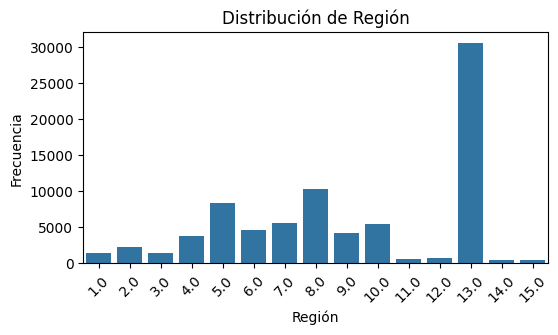

status
1.0    43966
2.0    10414
3.0     8232
4.0     6174
5.0    27900
NaN      110
Name: count, dtype: int64


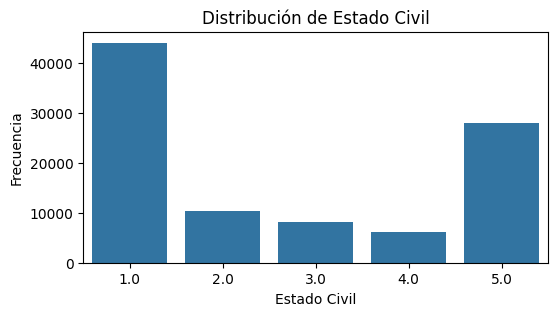

situation
1      250
2     8100
3    55777
4    32669
Name: count, dtype: int64


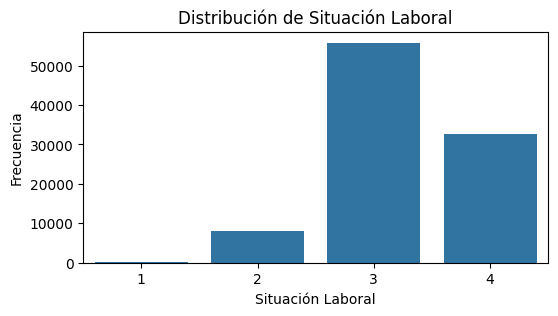

occupation
1.0      2034
2.0      3921
3.0      4406
4.0      5332
5.0      7700
6.0      2709
7.0      8219
8.0      5286
9.0     10109
10.0       49
NaN     47031
Name: count, dtype: int64


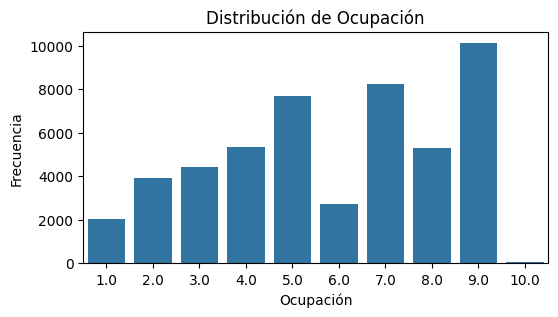

In [200]:
#Ahora veremos las distribuciones de estas variables.

# Region
print(df['region'].value_counts(dropna=False).sort_index())
plt.figure(figsize=(6,3))
sns.countplot(x='region', data=df, order=sorted(df['region'].dropna().unique()))
plt.title('Distribución de Región')
plt.xlabel('Región')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

# Status
print(df['status'].value_counts(dropna=False).sort_index())
plt.figure(figsize=(6,3))
sns.countplot(x='status', data=df, order=sorted(df['status'].dropna().unique()))
plt.title('Distribución de Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Frecuencia')
plt.show()

# situation
print(df['situation'].value_counts(dropna=False).sort_index())
plt.figure(figsize=(6,3))
sns.countplot(x='situation', data=df, order=sorted(df['situation'].dropna().unique()))
plt.title('Distribución de Situación Laboral')
plt.xlabel('Situación Laboral')
plt.ylabel('Frecuencia')
plt.show()

# occupation
print(df['occupation'].value_counts(dropna=False).sort_index())
plt.figure(figsize=(6,3))
sns.countplot(x='occupation', data=df, order=sorted(df['occupation'].dropna().unique()))
plt.title('Distribución de Ocupación')
plt.xlabel('Ocupación')
plt.ylabel('Frecuencia')
plt.show()

La variable región tiene muchos datos con "13", analizaremos esto. También aunque hay pocos faltantes en situation, por qué hay tantos en inactivo. Y por último veremos los datos faltantes en Occupation que son muchos.


In [201]:
# Dummie que marca 1 si la region cambia para un folio a lo largo del panel
df['region_inconsistente'] = df.groupby('folio_n20')['region'].transform(lambda x: int(x.nunique() > 1))
df['region_inconsistente'].mean()

np.float64(0.04948551593041035)

El 5% de los individuos presentan cambios en la variable region a lo largo del panel.

In [202]:
def imputar_region_modal(grupo):
    if grupo['region'].nunique() > 1:
        # Si tiene más de una región, imputo la moda
        moda = grupo['region'].mode()[0]
        grupo['region'] = moda
    return grupo

df = df.groupby('folio_n20').apply(imputar_region_modal).reset_index(drop=True)

In [203]:
#Cambiamos las categóricas poniendolas en una lista y transformándolas.

v_categoricas = [
    "region", "status", "situation", "lmp", "occupation", "hombre", "kids",
    "informal", "selfemp", "publicemp", "sistema", "cotizando", 
    "illness", "cronica", "nocronica", "mental"]
for var in v_categoricas:
    df[var] = df[var].astype('category')

#Detectaremos valores raros o sin sentido en estas variables.
for var in v_categoricas:
    print(f"\nFrecuencias de {var}:")
    print(df[var].value_counts(dropna=False))



Frecuencias de region:
region
 13.0    30507
NaN      15402
 8.0     10396
 5.0      8567
 10.0     6063
 7.0      5709
 6.0      4761
 9.0      4316
 4.0      3830
 2.0      2239
 1.0      1993
 3.0      1404
 12.0      764
 11.0      608
 14.0      128
 15.0      109
Name: count, dtype: int64

Frecuencias de status:
status
 1.0    43966
 5.0    27900
 2.0    10414
 3.0     8232
 4.0     6174
NaN       110
Name: count, dtype: int64

Frecuencias de situation:
situation
3    55777
4    32669
2     8100
1      250
Name: count, dtype: int64

Frecuencias de lmp:
lmp
2    52144
0    41019
1     3633
Name: count, dtype: int64

Frecuencias de occupation:
occupation
NaN      47031
 9.0     10109
 7.0      8219
 5.0      7700
 4.0      5332
 8.0      5286
 3.0      4406
 2.0      3921
 6.0      2709
 1.0      2034
 10.0       49
Name: count, dtype: int64

Frecuencias de hombre:
hombre
0.0    48884
1.0    47912
Name: count, dtype: int64

Frecuencias de kids:
kids
0    62237
1    34559
Name: cou


2. Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [211]:
df = df.set_index(['folio_n20', 'time'])

#Minimo cuadrado agrupado
y = df['expectancy']
X = df[['edu', 'hombre', 'children', 'kids', 'wage', 'size', 'is_working',
        'selfemp', 'publicemp', 'sistema', 'cotizando', 'illness',
        'cronica', 'nocronica', 'mental']]
X = sm.add_constant(X)

model = lmp.PanelOLS(y, X)
results = model.fit()
print(results.summary)

KeyError: "None of ['folio_n20', 'time'] are in the columns"


3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [212]:
X = df[['edu', 'hombre', 'children', 'kids', 'wage', 'size', 'is_working',
        'selfemp', 'publicemp', 'sistema', 'cotizando', 'illness',
        'cronica', 'nocronica', 'mental']]
model=lmp.PanelOLS(y,X, entity_effects=True)
fe=model.fit(cov_type="robust")
print(fe)

ValueError: exog does not have full column rank. If you wish to proceed with model estimation irrespective of the numerical accuracy of coefficient estimates, you can set check_rank=False.


4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

In [213]:
X = df[['edu', 'hombre', 'children', 'kids', 'wage', 'size', 'is_working',
        'selfemp', 'publicemp', 'sistema', 'cotizando', 'illness',
        'cronica', 'nocronica', 'mental']]
X=sm.add_constant(X)
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

ValueError: exog does not have full column rank. If you wish to proceed with model estimation irrespective of the numerical accuracy of coefficient estimates, you can set check_rank=False.


5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [ ]:
import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
 diff = fe.params-re.params
 psi = fe.cov - re.cov
 dof = diff.size -1
 W = diff.dot(la.inv(psi)).dot(diff)
 pval = stats.chi2.sf(W, dof)
 return W, dof, pval

htest = hausman(fe, re) 
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))


6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?


7. Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

9. Bonus track (optativo): Es posible que sus resultados anteriores tengan sesgo dado que quienes esperan vivir mas pueden estar incentivados a adquirir mas educacion. Proponga AL MENOS DOS instrumentos posibles para predecir el nivel de educacion de forma exogena, tal que se pueda corregir el sesgo y entender el efecto causal de las educacion en la expectativa de vida. Realice su estimacion considerando un modelo agrupado (ignorando el tiempo), y el modelo de panel.